<a href="https://colab.research.google.com/github/PrachiKumar298/CRISPR-gRNA-Efficinecy/blob/main/seed_window_ablation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Seed-Window Ablation — Standalone Cell

Run this **after** the main CLSA notebook has completed and models are saved.
It reloads everything from scratch so Colab runtime resets don't break it.

The `NameError: name 'build_cnn_short_lstm' is not defined` happened because
Cell 14 referenced functions defined in Cell 4, but the runtime had restarted
or Cell 4 had not been re-executed. This notebook is fully self-contained.


In [ ]:
# =====================================================================
# CELL A — Reinstall deps and re-download data
# (Skip if still in the same runtime)
# =====================================================================
!pip install lightgbm xgboost -q
import os
if not os.path.exists('/content/DeepHF'):
    !wget -q https://github.com/tranmanh2004/DeepHF/archive/refs/heads/main.zip
    !unzip -q main.zip
    !mv DeepHF-main DeepHF
    print('Data downloaded')
else:
    print('Data already present')

Data downloaded


In [ ]:
# =====================================================================
# CELL B — All imports + data loading (self-contained)
# =====================================================================
import pickle, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

from pathlib import Path
from scipy.stats import spearmanr
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# ── Data constants ──
DATA_DIR = Path('/content/DeepHF/data')
VARIANT_FILES = {
    'WT':      DATA_DIR / 'wt_seq_data_array.pkl',
    'eSpCas9': DATA_DIR / 'esp_seq_data_array.pkl',
    'HF1':     DATA_DIR / 'hf_seq_data_array.pkl',
}
VARIANT_IDX = {'WT': 0, 'eSpCas9': 1, 'HF1': 2}
inv_map = {0: 'WT', 1: 'eSpCas9', 2: 'HF1'}
SEQ_LEN = 20
N_BASES = 5
SEQ_SHAPE  = (SEQ_LEN, N_BASES)
CAS9_SHAPE = (3,)

INT_TO_BASE = {1:'A', 2:'T', 3:'C', 4:'G', 5:'N'}
BASE_ONEHOT = {'A':[1,0,0,0,0],'T':[0,1,0,0,0],'C':[0,0,1,0,0],'G':[0,0,0,1,0],'N':[0,0,0,0,1]}

def load_variant(path, variant_id):
    with open(path, 'rb') as f:
        try:    raw = pickle.load(f, encoding='latin1')
        except: raw = pickle.load(f)
    int_seqs   = raw[0]
    thermo     = raw[1]
    efficiency = raw[2]
    guide_ints = int_seqs[:, 1:21]
    N = len(guide_ints)
    guide_seqs = [''.join(INT_TO_BASE.get(int(b),'N') for b in row) for row in guide_ints]
    onehot = np.array([[BASE_ONEHOT[b] for b in seq] for seq in guide_seqs], dtype=np.float32)
    cas9 = np.zeros((N, 3), dtype=np.float32)
    cas9[:, variant_id] = 1.0
    return onehot, cas9, efficiency.astype(np.float32), thermo.astype(np.float32)

seqs, cas9s, effs, thermos = [], [], [], []
for vname, vpath in VARIANT_FILES.items():
    s, c, e, t = load_variant(vpath, VARIANT_IDX[vname])
    seqs.append(s); cas9s.append(c); effs.append(e); thermos.append(t)

X_seq   = np.concatenate(seqs,    axis=0)
X_cas9  = np.concatenate(cas9s,   axis=0)
X_thermo= np.concatenate(thermos, axis=0)
y       = np.concatenate(effs,    axis=0)
variant_labels = X_cas9.argmax(axis=1)

Xs_tr, Xs_te, Xc_tr, Xc_te, Xt_tr, Xt_te, y_tr, y_te, vl_tr, vl_te = train_test_split(
    X_seq, X_cas9, X_thermo, y, variant_labels,
    test_size=0.2, random_state=SEED, stratify=variant_labels
)
print(f'Train {len(y_tr):,}  |  Test {len(y_te):,}  — data ready')

Train 136,887  |  Test 34,222  — data ready


In [ ]:
# =====================================================================
# CELL C — Model builder (self-contained copy)
# =====================================================================
def build_cnn_short_lstm(k=5, lstm_units=64):
    """CNN + Short-Term LSTM restricted to last k positions."""
    seq_in  = keras.Input(shape=SEQ_SHAPE,  name='seq')
    cas9_in = keras.Input(shape=CAS9_SHAPE, name='cas9')

    x = layers.Conv1D(128, 3, padding='same', activation='relu')(seq_in)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, 5, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)             # (20, 128)

    # Crop to last k positions — seed region
    x_short = layers.Cropping1D(
        cropping=(SEQ_LEN - k, 0),
        name=f'seed_window_k{k}'
    )(x)                                           # (k, 128)

    lstm_out = layers.LSTM(
        lstm_units, dropout=0.2, name='short_lstm'
    )(x_short)                                     # (64,)

    x_pool = layers.GlobalAveragePooling1D(name='global_pool')(x)  # (128,)

    c = layers.Dense(16, activation='relu')(cas9_in)

    z = layers.Concatenate()([x_pool, lstm_out, c])
    z = layers.Dense(128, activation='relu')(z)
    z = layers.Dropout(0.3)(z)
    z = layers.Dense(64,  activation='relu')(z)
    z = layers.Dropout(0.2)(z)
    out = layers.Dense(1, activation='sigmoid')(z)

    return keras.Model(inputs=[seq_in, cas9_in], outputs=out,
                       name=f'CNN_ShortLSTM_k{k}')


def compile_and_train(model, Xs_tr, Xc_tr, y_tr,
                      epochs=80, batch_size=512, verbose=0):
    model.compile(optimizer=Adam(1e-3), loss='mse', metrics=['mae'])
    callbacks = [
        EarlyStopping(patience=8, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(factor=0.5, patience=4, min_lr=1e-5, verbose=0),
    ]
    history = model.fit(
        [Xs_tr, Xc_tr], y_tr,
        validation_split=0.1,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=verbose,
    )
    return history


def evaluate_model(model, Xs_te, Xc_te, y_te, vl_te):
    y_pred = model.predict([Xs_te, Xc_te], batch_size=1024, verbose=0).ravel()
    results = {}
    results['global_r2']  = r2_score(y_te, y_pred)
    results['global_rho'] = spearmanr(y_te, y_pred)[0]
    results['global_mse'] = float(np.mean((y_te - y_pred)**2))
    for vid, vname in inv_map.items():
        mask = vl_te == vid
        results[f'{vname}_r2']  = r2_score(y_te[mask], y_pred[mask])
        results[f'{vname}_rho'] = spearmanr(y_te[mask], y_pred[mask])[0]
    return results, y_pred

print('All functions defined — ready to run ablation')

All functions defined — ready to run ablation


In [ ]:
# =====================================================================
# CELL D — Seed-Window Ablation  k ∈ {3, 5, 8, 10, 20}
#
# k=20 = full-sequence LSTM (upper bound / sanity check)
# Note: k=5 already trained in the main notebook — included here for
# a clean standalone table but will retrain from scratch.
# =====================================================================
k_values   = [3, 5, 8, 10, 20]
k_r2_vals  = []
k_rho_vals = []
k_epochs   = []   # record actual epochs to report training efficiency

for k in k_values:
    print(f'\n──── k={k} ────')
    m = build_cnn_short_lstm(k=k)
    hist = compile_and_train(m, Xs_tr, Xc_tr, y_tr, epochs=80)
    res, _ = evaluate_model(m, Xs_te, Xc_te, y_te, vl_te)
    k_r2_vals.append(res['global_r2'])
    k_rho_vals.append(res['global_rho'])
    k_epochs.append(len(hist.history['loss']))
    print(f'  R²={res["global_r2"]:.4f}  ρ={res["global_rho"]:.4f}  '
          f'(stopped at epoch {k_epochs[-1]})')

# ── Results table ──
df_ablation = pd.DataFrame({
    'k': k_values,
    'R²': [f'{v:.4f}' for v in k_r2_vals],
    'Spearman ρ': [f'{v:.4f}' for v in k_rho_vals],
    'Epochs': k_epochs,
})
print('\n', df_ablation.to_string(index=False))
df_ablation.to_csv('lstm_ablation_results.csv', index=False)
print('\nSaved to lstm_ablation_results.csv')


──── k=3 ────
Restoring model weights from the end of the best epoch: 77.
  R²=0.7971  ρ=0.8895  (stopped at epoch 80)

──── k=5 ────
Epoch 68: early stopping
Restoring model weights from the end of the best epoch: 60.
  R²=0.8185  ρ=0.9016  (stopped at epoch 68)

──── k=8 ────
Epoch 67: early stopping
Restoring model weights from the end of the best epoch: 59.
  R²=0.8442  ρ=0.9164  (stopped at epoch 67)

──── k=10 ────
Epoch 67: early stopping
Restoring model weights from the end of the best epoch: 59.
  R²=0.8511  ρ=0.9203  (stopped at epoch 67)

──── k=20 ────
Epoch 70: early stopping
Restoring model weights from the end of the best epoch: 62.
  R²=0.8401  ρ=0.9141  (stopped at epoch 70)

  k     R² Spearman ρ  Epochs
 3 0.7971     0.8895      80
 5 0.8185     0.9016      68
 8 0.8442     0.9164      67
10 0.8511     0.9203      67
20 0.8401     0.9141      70

Saved to lstm_ablation_results.csv


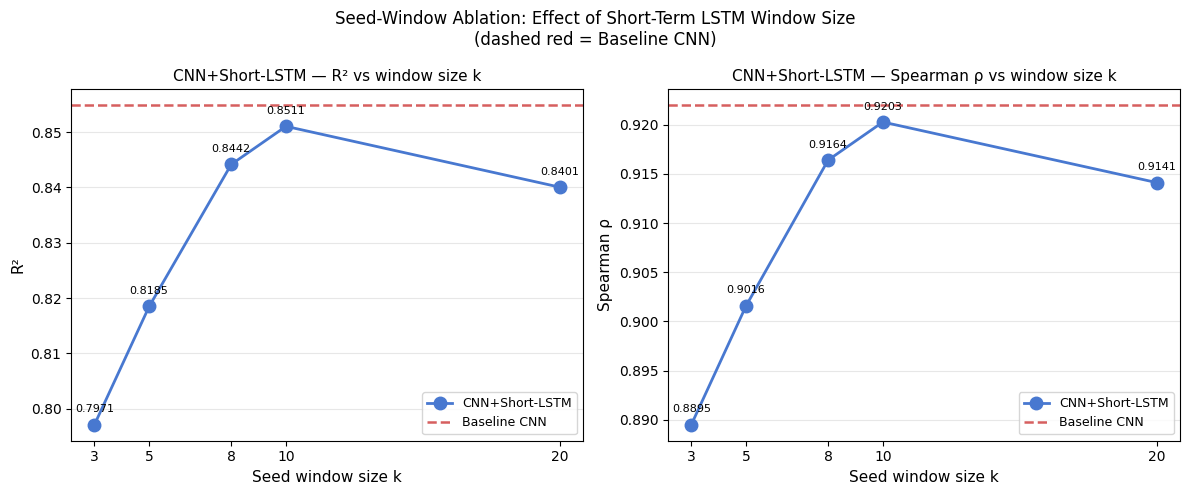

Saved lstm_window_ablation.pdf


In [ ]:
# =====================================================================
# CELL E — Ablation Plot
# =====================================================================
# Baseline CNN result from the main notebook run
BASELINE_R2  = 0.8549
BASELINE_RHO = 0.9220

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, vals, ylabel, bval in zip(
        axes,
        [k_r2_vals, k_rho_vals],
        ['R²', 'Spearman ρ'],
        [BASELINE_R2, BASELINE_RHO]):

    ax.plot(k_values, vals, 'o-', markersize=9, linewidth=2,
            color='#4878d0', label='CNN+Short-LSTM')
    ax.axhline(bval, color='#d65f5f', linestyle='--',
               linewidth=1.8, label='Baseline CNN')

    # Annotate each point
    for xv, yv in zip(k_values, vals):
        ax.annotate(f'{yv:.4f}', (xv, yv),
                    textcoords='offset points', xytext=(0, 9),
                    ha='center', fontsize=8)

    ax.set_xlabel('Seed window size k', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f'CNN+Short-LSTM — {ylabel} vs window size k', fontsize=11)
    ax.set_xticks(k_values)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Seed-Window Ablation: Effect of Short-Term LSTM Window Size\n'
             '(dashed red = Baseline CNN)', fontsize=12)
plt.tight_layout()
plt.savefig('lstm_window_ablation.pdf', bbox_inches='tight', dpi=150)
plt.show()
print('Saved lstm_window_ablation.pdf')

## Interpretation guide

| k | Expected behaviour |
|---|---|
| 3 | Only 3 PAM-proximal positions — may underfit local context |
| 5 | Canonical seed region — hypothesis: best trade-off |
| 8 | Extended seed — covers more context |
| 10 | Half sequence — starts to approach full-sequence LSTM |
| 20 | Full sequence — upper bound for recurrent capacity |

If R² peaks at k=5 and decreases for larger k, that confirms the biological prior (seed region is sufficient) and validates the truncation as a novel architectural choice.  
If R² increases monotonically toward k=20, that suggests full-sequence recurrence is still beneficial and the truncation should be argued differently in the paper.
